## 1. Study Objective

The goal of this clustering analysis is to identify meaningful population subgroups with distinct
**hypertension risk profiles**, **lifestyle behaviors**, and **health insurance coverage patterns**.

We use **SBP (systolic blood pressure)** and **DBP (diastolic blood pressure)** to define hypertension levels,
and aim to uncover subpopulations such as:

- High-risk hypertensive adults with poor insurance access  
- Low-risk young adults with higher uninsured rates  
- Moderate-risk groups with identifiable lifestyle characteristics  

These insights can inform targeted public health interventions and identify high-risk populations
who may benefit from improved healthcare access.

In [50]:
import pandas as pd

df = pd.read_csv("/Users/wmhjoy/Data_Mining_Project/data/processed/nhanes_clean_adult_add.csv")

df.shape
df.head()

,id,age,gender,race,education,income_poverty_ratio,weight_kg,height_cm,bmi,sbp,...,smoking_ever,physical_activity_freq,sleep_hours,diabetes_self_report,has_health_insurance,doctor_visit_12m,insurance_type,marital_status,household_size,is_employed
0,130378.0,43.0,Male,Non-Hispanic Asian,College graduate or above,5.00,86.9,179.5,27.0,135.0,...,Unknown,45.0,9.5,No,Insured,Yes,Private only,Married / living with partner,4.0,Yes
1,130379.0,66.0,Male,Non-Hispanic White,College graduate or above,5.00,101.8,174.2,33.5,121.0,...,Unknown,45.0,9.0,No,Insured,Unknown,Both,Married / living with partner,2.0,Yes
2,130380.0,44.0,Female,Other Hispanic,High school/GED,1.41,69.4,152.9,29.7,111.0,...,Unknown,30.0,8.0,Yes,Insured,Unknown,Public only,Married / living with partner,7.0,Yes
3,130384.0,43.0,Male,Mexican American,9-11th grade,0.63,87.5,176.0,28.3,120.0,...,Unknown,60.0,7.5,No,Not insured,Unknown,Uninsured,Never married,2.0,Yes
4,130385.0,65.0,Female,Non-Hispanic White,High school/GED,5.00,72.7,159.2,28.7,127.0,...,Unknown,60.0,8.0,No,Insured,No,Public only,Married / living with partner,2.0,No


## 2. Feature Selection and Preprocessing

We selected a combination of:

### **(1) Physiological Health Indicators**
- SBP(Systolic Blood Pressure)  
- DBP(Diastolic Blood Pressure)  
- BMI(Body Mass Index)  
- A1C (Glycemic biomarker) 

### **(2) Behavioral Health & Lifestyle Factors**
- Sleep hours (behavioral-health determinant)
- Smoking status (smoking_current) 

### **(3) Demographic**
- Age  
- Gender  
- Race
  
### **(4) Socioeconomic Variables (SES)**
- Education 
- Employment  
- Household size
- Income-to-poverty ratio
- Marital status  

### **(5) Insurance Coverage**
Used for profiling *BUT NOT* included in clustering input.

### Justification
To prevent outcome-driven or access-driven clusters, we intentionally exclude:
- **Insurance type**– reflects healthcare access, not underlying health or behavior
- **Hypertension stage(derived from SBP/DBP)**– an outcome variable directly computed from SBP/DBP, which are already included in the model
- **diabetes_self_report**– a disease outcome that could dominate clustering

These variables are later used for *cluster interpretation*, allowing us to evaluate how clinically relevant outcomes differ after clusters are formed, rather than letting these outcomes determine the clusters themselves.

In [51]:
numeric_features = [
    "age",
    "income_poverty_ratio",
    "bmi",
    "sbp",
    "dbp",
    "a1c",
    "sleep_hours",
    "household_size"
]
categorical_features = [
    "gender",
    "race",
    "education",
    "marital_status",
    "is_employed",
    "smoking_current"
]
clustering_features = numeric_features + categorical_features

df_cluster = df[clustering_features].copy()
df_cluster.head()

,age,income_poverty_ratio,bmi,sbp,dbp,a1c,sleep_hours,household_size,gender,race,education,marital_status,is_employed,smoking_current
0,43.0,5.00,27.0,135.0,98.0,5.6,9.5,4.0,Male,Non-Hispanic Asian,College graduate or above,Married / living with partner,Yes,Yes
1,66.0,5.00,33.5,121.0,84.0,5.6,9.0,2.0,Male,Non-Hispanic White,College graduate or above,Married / living with partner,Yes,Yes
2,44.0,1.41,29.7,111.0,79.0,6.2,8.0,7.0,Female,Other Hispanic,High school/GED,Married / living with partner,Yes,No
3,43.0,0.63,28.3,120.0,77.0,5.4,7.5,2.0,Male,Mexican American,9-11th grade,Never married,Yes,No
4,65.0,5.00,28.7,127.0,74.0,5.7,8.0,2.0,Female,Non-Hispanic White,High school/GED,Married / living with partner,No,No


In [52]:
from sklearn.preprocessing import StandardScaler

df_processed = df_cluster.copy()

for col in categorical_features:
    df_processed[col] = df_processed[col].astype(str)

scaler = StandardScaler()
df_processed[numeric_features] = scaler.fit_transform(df_processed[numeric_features])

df_processed.head()

,age,income_poverty_ratio,bmi,sbp,dbp,a1c,sleep_hours,household_size,gender,race,education,marital_status,is_employed,smoking_current
0,-0.492907,1.407966,-0.355640,0.792494,2.324926,-0.098965,1.092785,0.927300,Male,Non-Hispanic Asian,College graduate or above,Married / living with partner,Yes,Yes
1,0.746857,1.407966,0.640394,-0.057776,0.926581,-0.098965,0.781830,-0.419023,Male,Non-Hispanic White,College graduate or above,Married / living with partner,Yes,Yes
2,-0.439004,-0.945190,0.058097,-0.665112,0.427172,0.529187,0.159921,2.946786,Female,Other Hispanic,High school/GED,Married / living with partner,Yes,No
3,-0.492907,-1.456461,-0.156433,-0.118510,0.227408,-0.308349,-0.151034,-0.419023,Male,Mexican American,9-11th grade,Never married,Yes,No
4,0.692954,1.407966,-0.095139,0.306625,-0.072238,0.005727,0.159921,-0.419023,Female,Non-Hispanic White,High school/GED,Married / living with partner,No,No


## 3. Clustering Model: K-Prototypes

We apply **K-Prototypes** because the dataset contains both:

- Numerical variables (SBP, DBP, BMI, Age)
- Categorical variables (Smoking, Education, Employment)

K-Prototypes simultaneously minimizes:
- Euclidean distance for numeric features
- Matching dissimilarity for categorical features

We select **k = 4** based on:
- Medical interpretability (HTN severity)
- Elbow method results
- Cluster size stability

In [53]:
from kmodes.kprototypes import KPrototypes
import numpy as np

data_matrix = df_processed.to_numpy()

cost = []
K_range = [3, 4, 5]

for k in K_range:
    kproto = KPrototypes(n_clusters=k, init='Cao', n_init=5, verbose=0, random_state=42)
    clusters = kproto.fit_predict(data_matrix, categorical=[df_processed.columns.get_loc(c) for c in categorical_features])
    cost.append(kproto.cost_)

cost

[60476.64544585903, 56258.98218366698, 52183.574581189736]

In [54]:
best_k = 4

kproto_final = KPrototypes(
    n_clusters=best_k,
    init='Cao',
    n_init=5,
    verbose=0,
    random_state=42
)

clusters = kproto_final.fit_predict(
    data_matrix,
    categorical=[df_processed.columns.get_loc(c) for c in categorical_features]
)

df_processed['cluster'] = clusters

df_processed.groupby('cluster')[numeric_features].mean()

for col in categorical_features:
    print(col)
    print(df_processed.groupby('cluster')[col].value_counts(normalize=True))
    print("------")

gender
cluster  gender
0        Female    0.582833
         Male      0.417167
1        Female    0.638411
         Male      0.361589
2        Male      0.554516
         Female    0.445484
3        Female    0.547902
         Male      0.452098
Name: proportion, dtype: float64
------
race
cluster  race              
0        Non-Hispanic White    0.624827
         Non-Hispanic Black    0.127365
         Other Hispanic        0.085833
         Other Race / Multi    0.075681
         Mexican American      0.046608
         Non-Hispanic Asian    0.039686
1        Non-Hispanic White    0.425166
         Other Hispanic        0.157174
         Non-Hispanic Black    0.147020
         Mexican American      0.135982
         Other Race / Multi    0.076821
         Non-Hispanic Asian    0.057837
2        Non-Hispanic White    0.702604
         Non-Hispanic Black    0.076485
         Non-Hispanic Asian    0.068755
         Other Hispanic        0.065500
         Other Race / Multi    0.046786


In [55]:
df_processed.columns

Index(['age', 'income_poverty_ratio', 'bmi', 'sbp', 'dbp', 'a1c',
       'sleep_hours', 'household_size', 'gender', 'race', 'education',
       'marital_status', 'is_employed', 'smoking_current', 'cluster'],
      dtype='object')

In [56]:
df_raw = pd.read_csv("/Users/wmhjoy/Data_Mining_Project/data/processed/nhanes_clean_adult_add.csv")
df_raw.columns

Index(['id', 'age', 'gender', 'race', 'education', 'income_poverty_ratio',
       'weight_kg', 'height_cm', 'bmi', 'sbp', 'dbp', 'a1c', 'glucose',
       'smoking_current', 'smoking_ever', 'physical_activity_freq',
       'sleep_hours', 'diabetes_self_report', 'has_health_insurance',
       'doctor_visit_12m', 'insurance_type', 'marital_status',
       'household_size', 'is_employed'],
      dtype='object')

In [57]:
print(len(df_raw), len(df_processed))

df_raw['cluster'] = df_processed['cluster'].values

8153 8153


## 4. Clustering Results

Each individual in the dataset was assigned to one of four clusters.
We mapped each cluster to an interpretable label using hypertension severity
(SBP/DBP distribution) and insurance coverage characteristics.


In [58]:
cluster_labels = {
    0: "Moderate HTN, mostly public insured",
    1: "Low-risk, mixed public/private & more uninsured",
    2: "Mild HTN, mainly privately insured",
    3: "Severe HTN, mixed insurance coverage"
}

df_raw["cluster_label"] = df_raw["cluster"].map(cluster_labels)

df_raw[["cluster", "cluster_label"]].head()

,cluster,cluster_label
0,3,"Severe HTN, mixed insurance coverage"
1,2,"Mild HTN, mainly privately insured"
2,1,"Low-risk, mixed public/private & more uninsured"
3,1,"Low-risk, mixed public/private & more uninsured"
4,2,"Mild HTN, mainly privately insured"


## 5. Cluster Summary Table

The table below lists each of the four clusters and their corresponding descriptive labels.
These labels were derived based on hypertension severity (SBP/DBP levels), socioeconomic
patterns, and insurance coverage profiles observed in each cluster.

This summary serves as a reference point for all subsequent analyses.


In [59]:
summary_table = (
    df_raw[["cluster", "cluster_label"]]
    .drop_duplicates()
    .sort_values("cluster")
    .reset_index(drop=True)
)

summary_table

,cluster,cluster_label
0,0,"Moderate HTN, mostly public insured"
1,1,"Low-risk, mixed public/private & more uninsured"
2,2,"Mild HTN, mainly privately insured"
3,3,"Severe HTN, mixed insurance coverage"


## 6. Cluster Size Distribution

The bar chart below shows how many individuals fall into each cluster.  
Examining cluster size is crucial because:

- It reveals whether certain hypertension–lifestyle patterns dominate the population.
- It ensures clusters are reasonably balanced.
- It avoids over-interpreting very small clusters.

A balanced distribution increases the reliability of downstream interpretation.


8153 8153


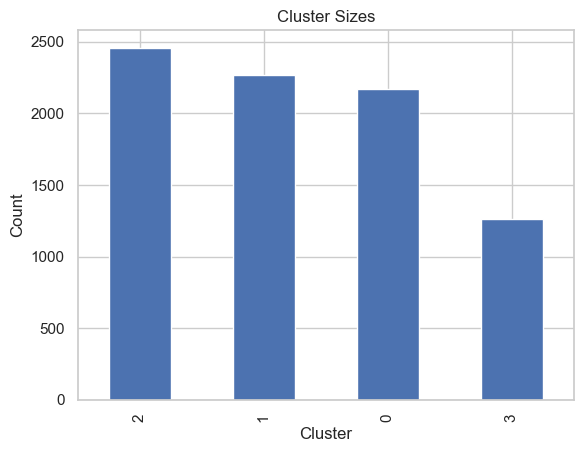

In [60]:
import matplotlib.pyplot as plt

print(len(df_raw), len(df_processed))

df_raw['cluster'] = df_processed['cluster'].values

df_raw['cluster'].value_counts().plot(kind='bar')
plt.title("Cluster Sizes")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.show()

## 7. Cluster Validity and Model Quality
Evaluating the quality and stability of clustering results is essential for ensuring that the identified groups are meaningful and interpretable.

Given the mixed data types in this dataset, the clustering analysis was performed using K-Prototypes and evaluated using **Gower distance–based silhouette scores**, **Intra-cluster variance**, and **cluster centroids**.

### 7.1 Silhouette Score
We computed the Silhouette Score using the Gower distance matrix, which is appropriate for **mixed numerical–categorical data**.

In [61]:
import gower
from sklearn.metrics import silhouette_score

gower_dist = gower.gower_matrix(df_processed.drop(columns=['cluster']))

sil_score = silhouette_score(gower_dist, df_processed['cluster'],
                             metric='precomputed')
print("Silhouette Score:", sil_score)

Silhouette Score: 0.075912684


**Silhouette Score Interpretation**

The silhouette score for the 4-cluster K-Prototypes model is **0.076**, which is close to zero.
This indicates that **clusters overlap substantially**, and the separation between groups is not strong.

This pattern is expected because:

- Health metrics (SBP, DBP, BMI, A1C) naturally overlap across individuals

- Socioeconomic variables (education, income, employment) vary gradually rather than being clearly separated

- Insurance types do not form distinct natural clusters in the population

- Mixed-type distance metrics (Gower) typically yield lower silhouette scores

Therefore, the clustering should be interpreted as identifying meaningful subpopulation patterns, rather than discovering naturally well-separated groups.

### 7.2 Intra-cluster Variance
To assess the internal consistency of each cluster, we compute the within-cluster variance for all numerical attributes. Lower variance indicates tighter grouping and higher internal similarity, while higher variance reflects more heterogeneous populations.

In [80]:
intra_var = df_processed.groupby("cluster")[numeric_features].var()
print("Intra-cluster variance:")
print(intra_var)

Intra-cluster variance:
              age  income_poverty_ratio       bmi       sbp       dbp  \
cluster                                                                 
0        0.294453              0.517300  0.594065  0.638280  0.582088   
1        0.426346              0.601847  0.900614  0.346528  0.537153   
2        0.680614              0.293532  0.587659  0.468653  0.549163   
3        0.534743              0.904916  1.900174  1.349725  1.069494   

              a1c  sleep_hours  household_size  
cluster                                         
0        0.817507     3.088440        0.396888  
1        0.185859     2.549380        1.084883  
2        0.240372     1.630379        0.445144  
3        3.215593     3.094341        0.841527  


**Intra-Cluster Variance Summary**
- Cluster 1 shows the **lowest variance**, consistent with a young, low-risk, and behaviorally homogeneous group.

- Cluster 3 has the **highest variance**, aligning with its older population and broad range of hypertension severity.

- Clusters 0 and 2 show **moderate variance**, reflecting mixed SES and mixed insurance groups.


### 7.3 Cluster Centroids
The K-Prototypes algorithm outputs centroids that summarize both numerical means and categorical modal values, providing an interpretable representation of each cluster’s socioeconomic, behavioral, and health profile.

In [81]:
prototypes = kproto_final.cluster_centroids_
print("Cluster centroids:")
print(prototypes)

Cluster centroids:
[['0.8730199986532764' '-0.5121074944034377' '-0.08736015493669068'
  '0.14443545578544234' '-0.3121015096052984' '0.20646308518700207'
  '0.2665377527818011' '-0.5407949408788704' 'Female'
  'Non-Hispanic White' 'High school/GED' 'Widowed / divorced / separated'
  'No' 'Yes']
 ['-1.030339790388816' '-0.5380371393951842' '-0.19446126240629147'
  '-0.6544936197366779' '-0.3991135936507207' '-0.3914089901206005'
  '0.021810082373742684' '0.8934193653737671' 'Female'
  'Non-Hispanic White' 'Some college/AA' 'Married / living with partner'
  'Yes' 'No']
 ['0.004674348171580075' '1.020025062916693' '-0.15822847016890818'
  '-0.17704431015047875' '-0.06463878920603505' '-0.2188196959070291'
  '-0.21074542005157487' '-0.3075598577650335' 'Male'
  'Non-Hispanic White' 'College graduate or above'
  'Married / living with partner' 'Yes' 'No']
 ['0.34077255767480047' '-0.1415918792927733' '0.8065635746422932'
  '1.2704761127208193' '1.3770375334932605' '0.7735508072544757'
  '-

**Cluster Centroid Summary**
- Cluster 0: High smoking prevalence, lower SES, predominantly public insurance.

- Cluster 1: Young, low hypertension, higher uninsured proportion.

- Cluster 2: Higher income/education, private insurance, mild hypertension.

- Cluster 3: Older adults, high SBP/DBP, high Stage 2 HTN proportion, mixed insurance.

## 8. Cluster Profiles

To understand the characteristics of each cluster, we summarize the major dimensions along which clusters differ:

- Socioeconomic Structure
(income, age, sleep, household size — the strongest drivers of segmentation)

- Physiological Health Risk
(SBP, DBP, BMI — capturing the hypertension gradient across clusters)

- Behavioral & Social Structure
(smoking, employment, education — shaping lifestyle risk)

- Insurance Access & Hypertension Stage
(the policy-relevant outcomes that motivate our analysis)

Together, these visualizations form a coherent body of evidence that characterizes each cluster across socioeconomic, behavioral, and physiological dimensions.


### 8.1 Feature Importance: Identifying Key Drivers of the Clustering Structure

Although K-Prototypes is an unsupervised algorithm and does not intrinsically generate feature importance scores, we estimate variable contributions using a **permutation-based stability method**.
For each variable, we randomly permute its values and measure the resulting change in cluster assignments. Features that cause larger disruptions are considered more influential in determining the cluster structure.

The results provide a **data-driven foundation** for selecting which variables to visualize in subsequent subsections.
This ensures that our analysis is **coherent**, **focused**, and **statistically justified**, rather than a collection of unrelated plots.

In [63]:
import numpy as np
import pandas as pd
from kmodes.kprototypes import KPrototypes
from sklearn.metrics import adjusted_rand_score
import matplotlib.pyplot as plt

original_labels = df_processed['cluster'].values

all_features = numeric_features + categorical_features

feature_importance = {}

for feat in all_features:
    df_temp = df_processed.copy()
    
    df_temp[feat] = np.random.permutation(df_temp[feat].values)
    
    temp_matrix = df_temp.drop(columns=['cluster']).to_numpy()
    
    kproto_tmp = KPrototypes(
        n_clusters=best_k,
        init='Cao',
        n_init=1,
        verbose=0,
        random_state=42
    )
    tmp_labels = kproto_tmp.fit_predict(
        temp_matrix,
        categorical=[df_temp.columns.get_loc(c) for c in categorical_features]
    )
    
    ari = adjusted_rand_score(original_labels, tmp_labels)
    importance = 1 - ari   
    feature_importance[feat] = importance

importance_df = (
    pd.DataFrame.from_dict(feature_importance, orient="index", columns=["importance"])
    .sort_values("importance", ascending=False)
)

importance_df

,importance
age,0.586697
income_poverty_ratio,0.561133
sleep_hours,0.417963
household_size,0.407856
dbp,0.319300
sbp,0.307460
bmi,0.245882
smoking_current,0.215977
is_employed,0.215659
education,0.204760


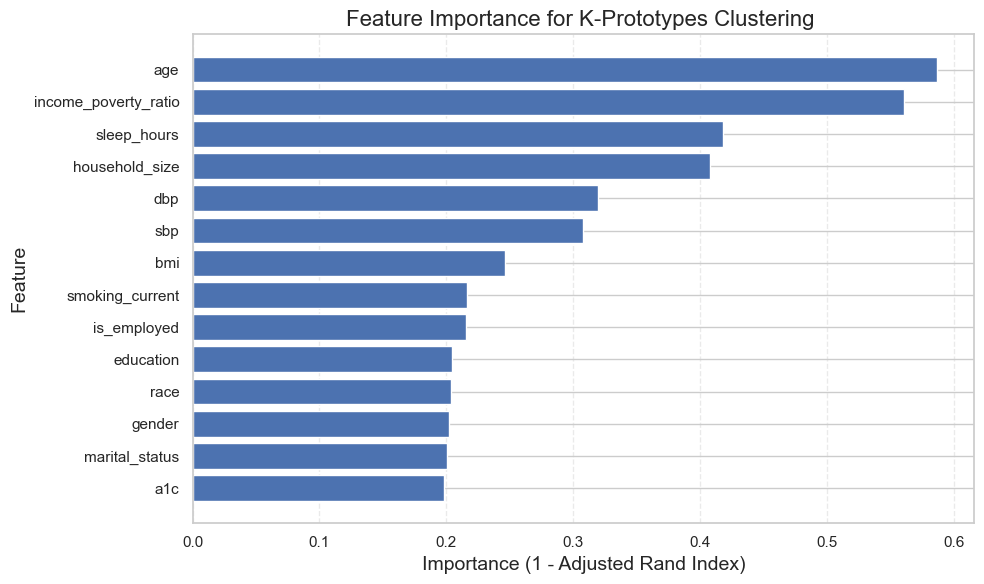

In [64]:
plt.figure(figsize=(10, 6))
plt.barh(
    importance_df.index,
    importance_df['importance'],
    color="#4C72B0"
)
plt.gca().invert_yaxis()

plt.title("Feature Importance for K-Prototypes Clustering ", 
          fontsize=16)
plt.xlabel("Importance (1 - Adjusted Rand Index)", fontsize=14)
plt.ylabel("Feature", fontsize=14)

plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

To guide our subsequent visualization and interpretation, we group the features into three importance tiers:

- **Tier 1 — Main contextual drivers**

These variables (**income-to-poverty ratio, household size, age**) define the structural axes along which clusters separate. They show the highest permutation importance and therefore represent the backbone of the cluster structure.

- **Tier 2 — Physiological risk indicators**

Variables such as **blood pressure (SBP/DBP) and BMI** capture underlying cardiometabolic health risk. Their importance is moderate: they refine cluster separation but do not dominate it.

- **Tier 3 — Behavioral & social refinements**

**Employment status, smoking, education, marital status, gender, and race** further distinguish clusters through lifestyle and demographic nuances. They show lower importance and function as secondary refinements rather than core drivers.

This section motivates the following analyses by showing that we will focus on **the most influential variables** when characterizing cluster profiles.

### 8.2 Contextual Drivers: Socioeconomic & Demographic Structure
This section focuses on the **structural background variables (Tier-1 importance)** that anchor the interpretation of the four clusters. These features describe fundamental demographic and socioeconomic conditions shaping each group’s health context.

We examine three core variables:

- **Income-to-poverty ratio** (primary SES indicator)

- **Household size** (family/structural context)

- **Age** (population demographic structure)

These variables provide the foundation for understanding differences in socioeconomic resources, family structure, and demographic risk across clusters.

/var/folders/f2/ms2jwb5x6ml5ggd3pv6bzx2m0000gn/T/ipykernel_1434/2754196297.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/f2/ms2jwb5x6ml5ggd3pv6bzx2m0000gn/T/ipykernel_1434/2754196297.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/f2/ms2jwb5x6ml5ggd3pv6bzx2m0000gn/T/ipykernel_1434/2754196297.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


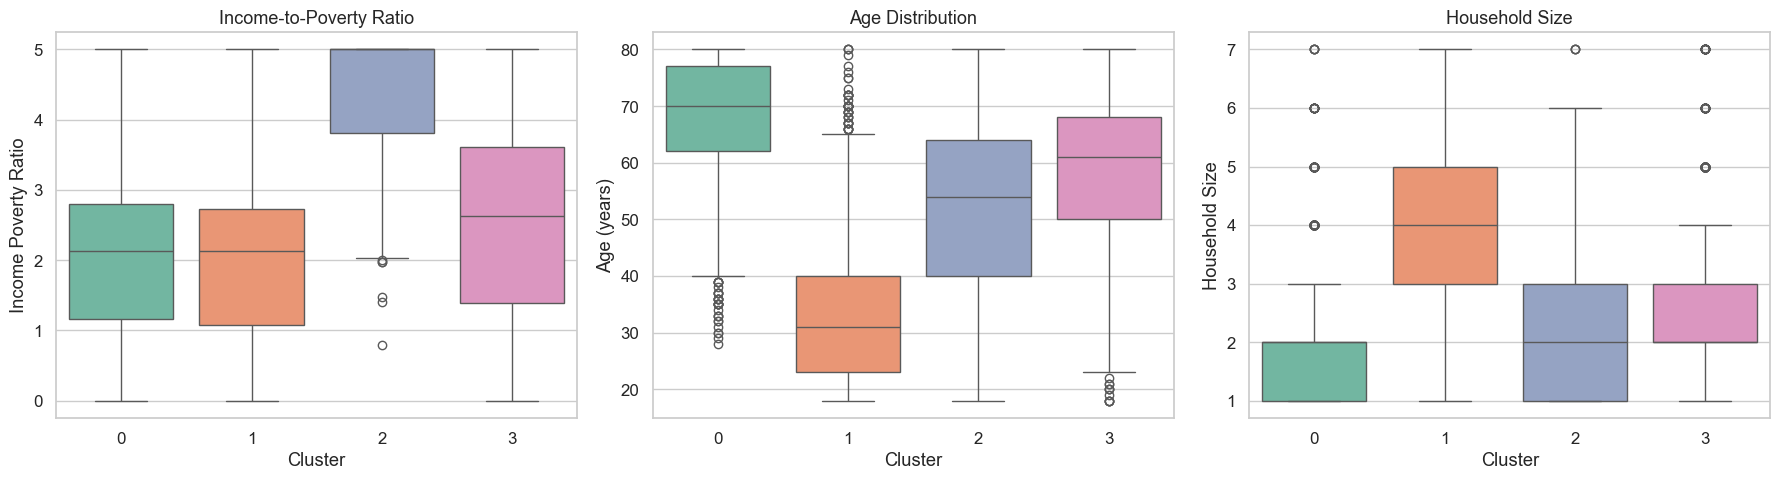

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", palette="Set2", font_scale=1.1)

df_plot = df_raw.copy()
df_plot["cluster"] = df_processed["cluster"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(
    x="cluster",
    y="income_poverty_ratio",
    data=df_plot,
    palette="Set2",
    ax=axes[0]
)
axes[0].set_title("Income-to-Poverty Ratio", fontsize=13)
axes[0].set_xlabel("Cluster")
axes[0].set_ylabel("Income Poverty Ratio")

sns.boxplot(
    x="cluster",
    y="age",
    data=df_plot,
    palette="Set2",
    ax=axes[1]
)
axes[1].set_title("Age Distribution", fontsize=13)
axes[1].set_xlabel("Cluster")
axes[1].set_ylabel("Age (years)")

sns.boxplot(
    x="cluster",
    y="household_size",
    data=df_plot,
    palette="Set2",
    ax=axes[2]
)
axes[2].set_title("Household Size", fontsize=13)
axes[2].set_xlabel("Cluster")
axes[2].set_ylabel("Household Size")

plt.tight_layout()
plt.show()

### 8.3 Physiological Health Risk Profile

To understand how physiological risk factors differentiate the clusters, we examine four Tier-2 variables that capture cardiometabolic health:

- **SBP (systolic blood pressure)**  
- **DBP (diastolic blood pressure)**  
- **BMI (body mass index)**  

These features show moderate importance in the permutation analysis, suggesting that physiological differences refine, but do not dominate, cluster separation.


/var/folders/f2/ms2jwb5x6ml5ggd3pv6bzx2m0000gn/T/ipykernel_1434/3722372441.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/f2/ms2jwb5x6ml5ggd3pv6bzx2m0000gn/T/ipykernel_1434/3722372441.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/f2/ms2jwb5x6ml5ggd3pv6bzx2m0000gn/T/ipykernel_1434/3722372441.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


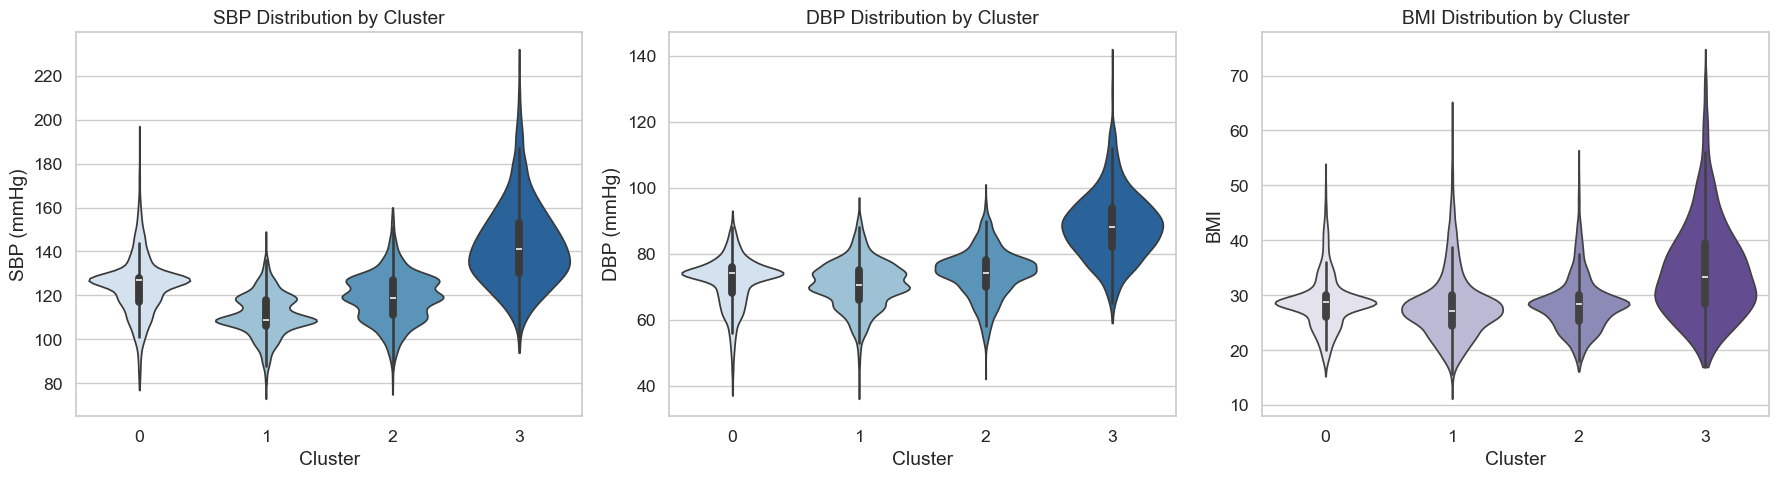

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", palette="Set2", font_scale=1.15)

df_plot = df_raw.copy()
df_plot["cluster"] = df_processed["cluster"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.violinplot(
    data=df_plot,
    x="cluster",
    y="sbp",
    ax=axes[0],
    palette="Blues",
    inner="box",   
    cut=0
)
axes[0].set_title("SBP Distribution by Cluster")
axes[0].set_xlabel("Cluster")
axes[0].set_ylabel("SBP (mmHg)")

sns.violinplot(
    data=df_plot,
    x="cluster",
    y="dbp",
    ax=axes[1],
    palette="Blues",
    inner="box",
    cut=0
)
axes[1].set_title("DBP Distribution by Cluster")
axes[1].set_xlabel("Cluster")
axes[1].set_ylabel("DBP (mmHg)")

sns.violinplot(
    data=df_plot,
    x="cluster",
    y="bmi",
    ax=axes[2],
    palette="Purples",
    inner="box",
    cut=0
)
axes[2].set_title("BMI Distribution by Cluster")
axes[2].set_xlabel("Cluster")
axes[2].set_ylabel("BMI")

plt.tight_layout()
plt.show()

The physiological profiles across clusters show consistent and clinically meaningful differences:

- Cluster 3 is the only cluster with systematically elevated SBP, DBP, and BMI, indicating the highest cardiometabolic risk.

- Cluster 1 exhibits the healthiest overall profile, with the lowest blood pressure and BMI.

- Cluster 0 falls into a borderline-normal range, reflecting low-to-moderate risk.

- Cluster 2 is an intermediate and heterogeneous group, neither clearly healthy nor high-risk.

### 8.4 Behavioral & Social Patterns

To complement the physiological comparison in Section 8.3, this section examines
key behavioral and social-role indicators (Tier-3 variables). These variables do not
primarily determine the cluster assignments, but they provide important context on
lifestyle and social positioning, helping us understand why some clusters remain more
vulnerable despite similar physiological profiles.

### Variables Included
- **sleep_hours** (core lifestyle behavior)
- **smoking_current** (health-risk behavior)
- **is_employed** (economic stability & social participation)
- **education** (social capital & health literacy)

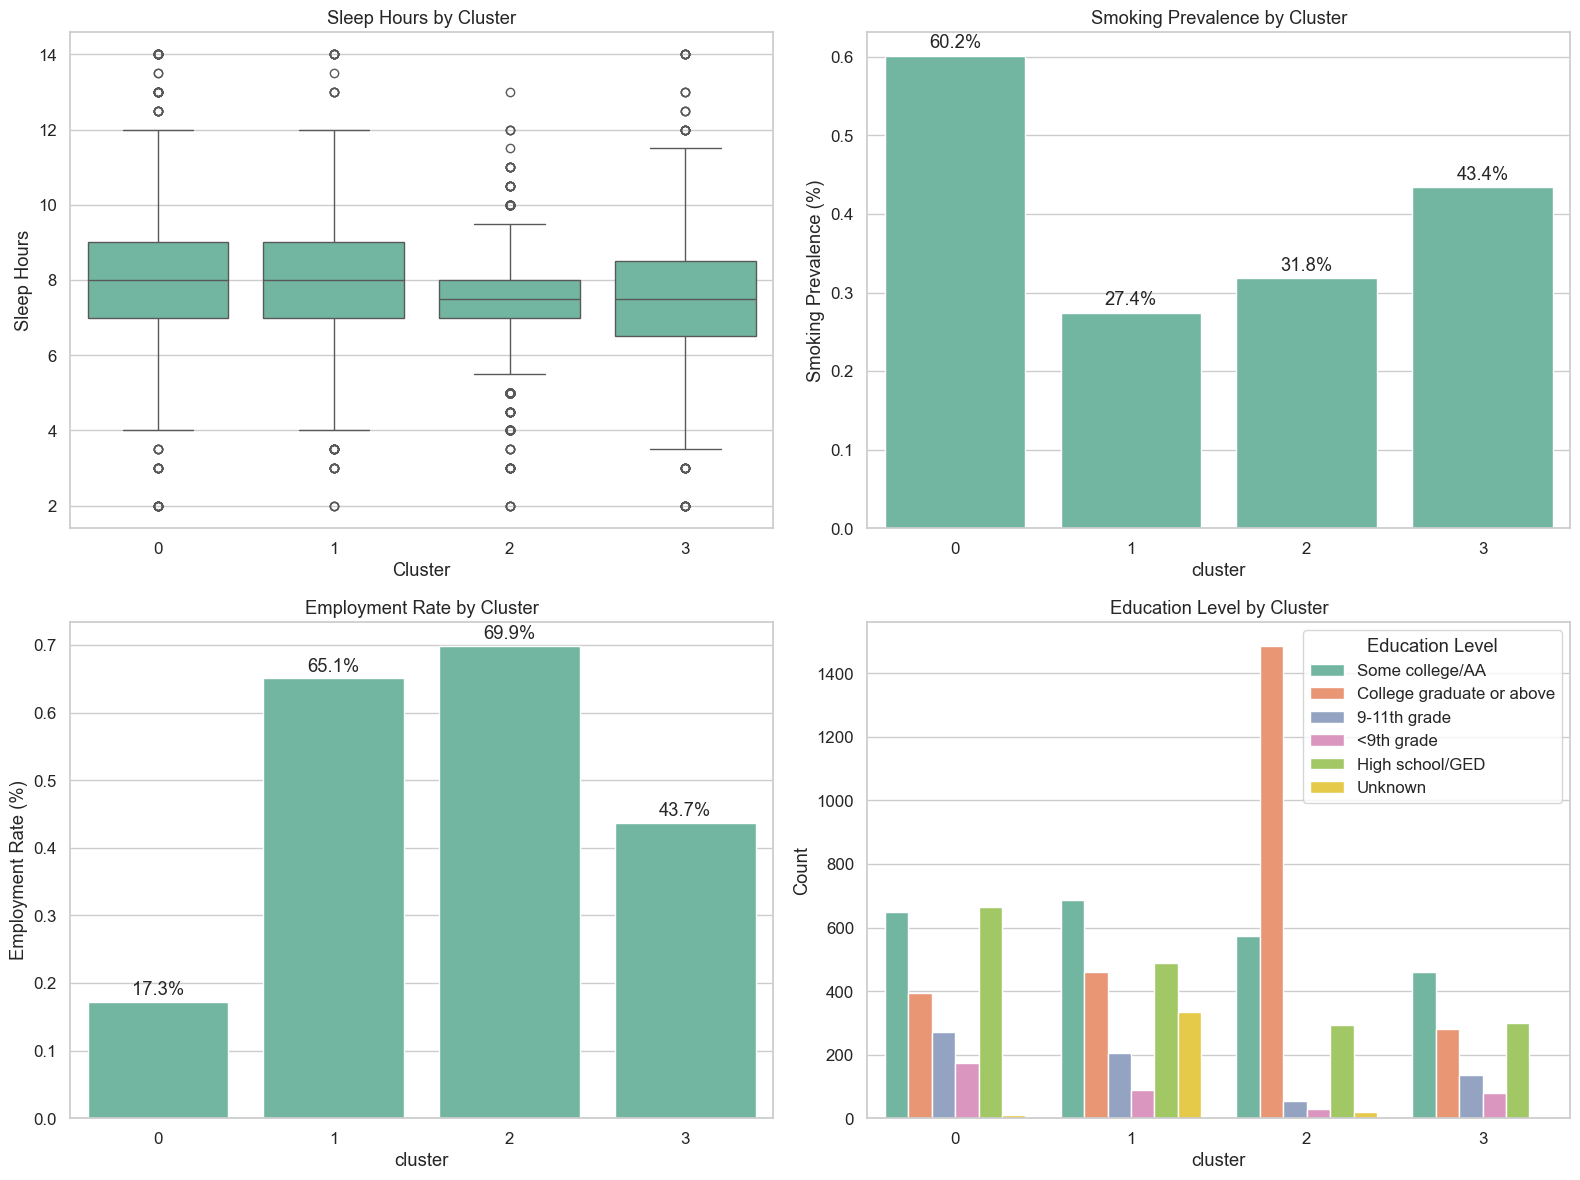

In [67]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid", palette="Set2", font_scale=1.1)

df_raw = pd.read_csv("/Users/wmhjoy/Data_Mining_Project/data/processed/nhanes_clean_adult_add.csv")

df_processed["smoking_current"] = df_raw["smoking_current"].map({"Yes": 1, "No": 0})
df_processed["is_employed"] = df_raw["is_employed"].map({"Yes": 1, "No": 0})

df_processed["sleep_hours"] = pd.to_numeric(df_raw["sleep_hours"], errors="coerce")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.boxplot(
    data=df_processed,
    x="cluster",
    y="sleep_hours",
    ax=axes[0, 0]
)
axes[0, 0].set_title("Sleep Hours by Cluster")
axes[0, 0].set_xlabel("Cluster")
axes[0, 0].set_ylabel("Sleep Hours")

smoke_rate = (
    df_processed.groupby("cluster")["smoking_current"]
    .mean()
    .reset_index()
)

sns.barplot(
    data=smoke_rate,
    x="cluster",
    y="smoking_current",
    ax=axes[0, 1]
)

axes[0, 1].set_title("Smoking Prevalence by Cluster")
axes[0, 1].set_ylabel("Smoking Prevalence (%)")

for i, row in smoke_rate.iterrows():
    axes[0, 1].text(i, row["smoking_current"] + 0.01, f"{row['smoking_current']*100:.1f}%", ha="center")

employ_rate = (
    df_processed.groupby("cluster")["is_employed"]
    .mean()
    .reset_index()
)

sns.barplot(
    data=employ_rate,
    x="cluster",
    y="is_employed",
    ax=axes[1, 0]
)

axes[1, 0].set_title("Employment Rate by Cluster")
axes[1, 0].set_ylabel("Employment Rate (%)")

for i, row in employ_rate.iterrows():
    axes[1, 0].text(i, row["is_employed"] + 0.01, f"{row['is_employed']*100:.1f}%", ha="center")

sns.countplot(
    data=df_processed,
    x="cluster",
    hue="education",
    ax=axes[1, 1]
)
axes[1, 1].set_title("Education Level by Cluster")
axes[1, 1].set_ylabel("Count")
axes[1, 1].legend(title="Education Level")

plt.tight_layout()
plt.show()

### 8.5 Insurance Type & Hypertension Stage Distribution
Finally, because the primary goal of our project is to identify population subgroups with high hypertension risk and limited insurance coverage, we analyze each cluster’s:

- **Insurance type distribution**
- **Hypertension stages**

These outcome-focused visualizations directly support the interpretation in Section 9 and help identify vulnerable population groups who may require targeted health interventions or policy support.

In [74]:
df_processed["insurance_type"] = df_raw["insurance_type"]
insurance_type = df_processed.groupby(["cluster", "insurance_type"]).size().reset_index(name="count")
insurance_type["proportion"] = insurance_type.groupby("cluster")["count"].transform(lambda x: x / x.sum())

insurance_wide = insurance_type.pivot(index="cluster", 
                                      columns="insurance_type", 
                                      values="proportion").fillna(0)
insurance_wide

insurance_type,Both,Private only,Public only,Uninsured,Unknown
cluster,,,,,
0,0.285648,0.077527,0.572220,0.055838,0.008768
1,0.024283,0.377483,0.401325,0.162472,0.034437
2,0.155004,0.620830,0.175346,0.041904,0.006916
3,0.179731,0.293745,0.429137,0.091053,0.006334


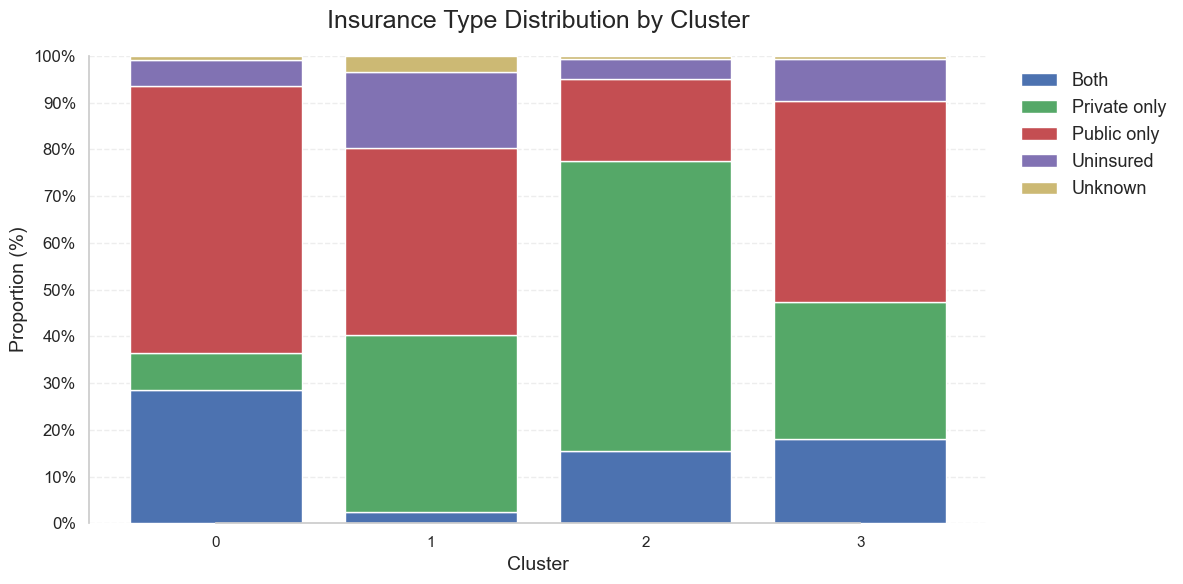

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

nature_insurance_colors = {
    "Both":         "#4C72B0",  
    "Private only": "#55A868",  
    "Public only":  "#C44E52",  
    "Uninsured":    "#8172B3",  
    "Unknown":      "#CCB974",  
}

sns.set_theme(style="whitegrid")

df_plot = insurance_wide.copy()*100
clusters = df_plot.index.astype(str)

bottom = np.zeros(len(df_plot))

fig, ax = plt.subplots(figsize=(12, 6))

for col in df_plot.columns:
    values = df_plot[col]
    ax.bar(
        clusters,
        values,
        bottom=bottom,
        label=col,
        color=nature_insurance_colors[col],
        edgecolor="white"
    )
    bottom += values

ax.set_ylabel("Proportion (%)", fontsize=14)
ax.set_xlabel("Cluster", fontsize=14)
plt.title("Insurance Type Distribution by Cluster", fontsize=18, pad=20)

ax.set_ylim(0, 100)
ax.set_yticks(np.arange(0, 101, 10))
ax.set_yticklabels([f"{i}%" for i in range(0, 101, 10)], fontsize=12)

ax.grid(True, axis='y', linestyle='--', alpha=0.35)
ax.grid(False, axis='x')

plt.legend(frameon=False, fontsize=13, bbox_to_anchor=(1.02, 1), loc="upper left")

sns.despine(trim=True)

plt.tight_layout()
plt.show()

In [76]:
def classify_hypertension_stage(row):
    sbp = row['sbp']
    dbp = row['dbp']

    if pd.isna(sbp) or pd.isna(dbp):
        return None  

    if sbp >= 140 or dbp >= 90:
        return "Stage 2"
    elif sbp >= 130 or dbp >= 80:
        return "Stage 1"
    else:
        return "Normal"

Hypertension Wide Table (%):
htn_stage     Normal    Stage 1    Stage 2
cluster                                   
0          72.219659  17.628057  10.152284
1          89.403974   9.624724   0.971302
2          74.694874  20.260374   5.044752
3           8.076010  24.623911  67.300079


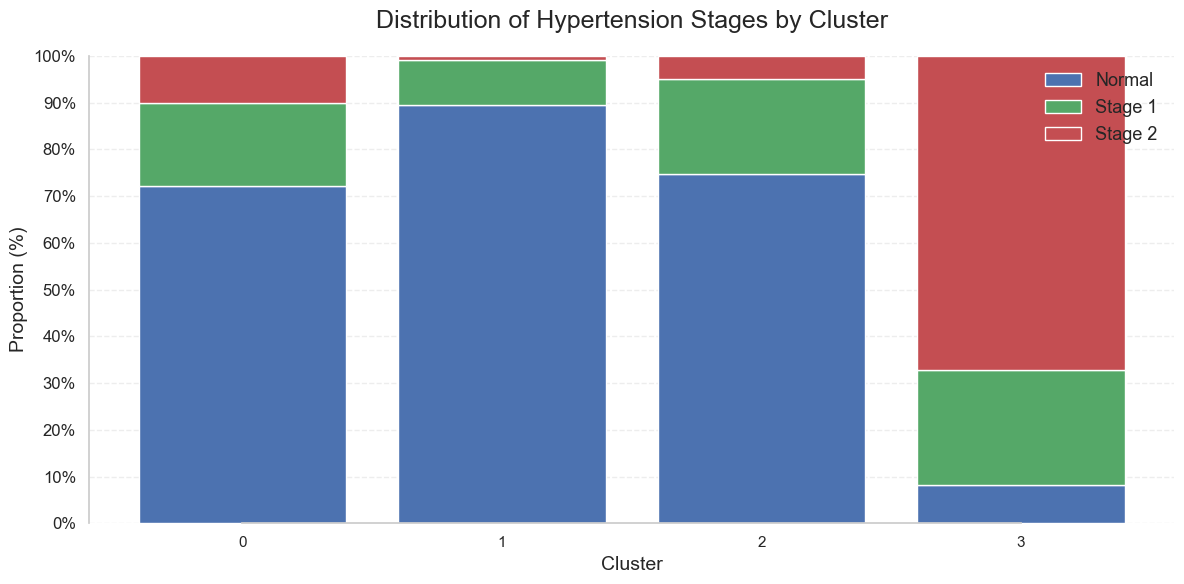

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df_raw['htn_stage'] = df_raw.apply(classify_hypertension_stage, axis=1)

mapping = {"Normal": 0, "Stage 1": 1, "Stage 2": 2}
df_raw["htn_stage_num"] = df_raw["htn_stage"].map(mapping)
df_processed["htn_stage"] = df_raw["htn_stage"]

htn_table = (
    df_processed.groupby(["cluster", "htn_stage"])
    .size()
    .reset_index(name="count")
)

htn_table["proportion"] = (
    htn_table.groupby("cluster")["count"].transform(lambda x: x / x.sum())
)

htn_wide = htn_table.pivot(
    index="cluster",
    columns="htn_stage",
    values="proportion"
).fillna(0)

desired_cols = ["Normal", "Stage 1", "Stage 2"]
htn_wide = htn_wide.reindex(columns=desired_cols, fill_value=0)

print("Hypertension Wide Table (%):")
print(htn_wide * 100)

sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(12, 6))

clusters = htn_wide.index.astype(str)

normal_pct = htn_wide["Normal"] * 100
stage1_pct = htn_wide["Stage 1"] * 100
stage2_pct = htn_wide["Stage 2"] * 100

colors = {
    "Normal": "#4C72B0",
    "Stage 1": "#55A868",
    "Stage 2": "#C44E52",
}

ax.bar(clusters, normal_pct, color=colors["Normal"], label="Normal")
ax.bar(clusters, stage1_pct, bottom=normal_pct, color=colors["Stage 1"], label="Stage 1")
ax.bar(clusters, stage2_pct, bottom=normal_pct + stage1_pct,
       color=colors["Stage 2"], label="Stage 2")

ax.set_ylabel("Proportion (%)", fontsize=14)
ax.set_xlabel("Cluster", fontsize=14)
plt.title("Distribution of Hypertension Stages by Cluster",
          fontsize=18, pad=20)

ax.set_ylim(0, 100)
ax.set_yticks(range(0, 101, 10))
ax.set_yticklabels([f"{i}%" for i in range(0, 101, 10)], fontsize=12)

ax.grid(True, axis="y", linestyle="--", alpha=0.35)
ax.grid(False, axis="x")

plt.legend(frameon=False, fontsize=13, loc="upper right")

sns.despine(trim=True)
plt.tight_layout()
plt.show()

In [1]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. 选择 clustering 时用到的特征
num_features = ["sbp","dbp","bmi","a1c","age","income_poverty_ratio"]
cat_features = ["smoking_current","education","employment","race","marital_status"]

features = num_features + cat_features

X = df_processed[features]
y = df_processed["cluster"]

# 2. One-hot encode 类别变量
ct = ColumnTransformer(
    transformers=[
        ("onehot", OneHotEncoder(sparse=False, handle_unknown="ignore"), cat_features)
    ],
    remainder="passthrough"
)

# 3. PCA 管道
pca_pipeline = Pipeline([
    ("encoder", ct),
    ("pca", PCA(n_components=2))
])

X_pca = pca_pipeline.fit_transform(X)

# 4. 转成 dataframe 方便画图
pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "cluster": y
})

# 5. 绘图
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=pca_df,
    x="PC1", y="PC2",
    hue="cluster",
    palette="tab10",
    s=20,
    alpha=0.7
)

plt.title("Clusters in PCA Space")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Cluster ID")
plt.show()


NameError: name 'df_processed' is not defined

## 9. Cluster Interpretation

### Cluster 0 — Low-Income Lifestyle-Risk Group: Moderate HTN, mostly public insured
**Key Evidence**

- Income-to-poverty ratio lowest → clear low-SES pattern

- Age is oldest on average (≈ 65–80 yrs)

- Smoking prevalence highest (≈ 60%)

- Employment rate lowest (≈ 17%)

- HTN distribution:
  - Normal: 72%

  - Stage 1: 18%

  - Stage 2: 10%

- Insurance mainly **public** (Medicaid/Medicare)

**Interpretation**

Cluster 0 represents an older, low-income population with high behavioral risks and moderate hypertension. Limited resources and high dependency on public insurance suggest barriers to preventive care. This group would benefit the most from community health outreach and chronic disease management support.

### Cluster 1 — Young, Healthy, but Uninsured: Low-risk, mixed public/private & more uninsured
**Key Evidence**

- Youngest group (≈ 25–40 yrs)

- Highest proportion of Normal BP (≈ 89%)

- Lowest Stage 2 HTN (≈ 1%)

- Employment high (≈ 65%)

- Uninsured rate noticeably higher than other groups

- SES moderately low but stable

**Interpretation**

This is the healthiest and youngest cluster. Despite good physiological indicators and lower hypertension risk, the higher uninsured rate suggests possible gaps in preventive care access. They are low-risk now, but lack of insurance may delay early detection of future health issues.

### Cluster 2 — Well-Resourced, Protected, Low-Risk Group: Mild HTN, mainly privately insured
**Key Evidence**

- Highest income-to-poverty ratio → highest SES

- Education level highest

- Employment highest (≈ 70%)

- Private insurance dominates

- HTN distribution:

  - Normal: 75%

  - Stage 1: 20%

  - Stage 2: 5%

- Low BMI  → lifestyle relatively healthy

**Interpretation**

Cluster 2 represents a stable, high-SES group with strong access to healthcare and insurance protection. Mild hypertension appears but remains manageable. High resources and consistent care access likely protect this group from progressing to more severe cardiovascular risks.

### Cluster 3 — Older, High-Risk Hypertension Group: Severe HTN, mixed insurance coverage
**Key Evidence**

- Age second-highest (≈ 50–70 yrs)

- Stage 2 hypertension extremely high (≈ 67%)

- BMI highest of all clusters

- Smoking high (≈ 43%)

- Insurance type mixed (public + private + uninsured)

- Employment moderate

**Interpretation**

Cluster 3 is the most clinically concerning group. Physiological measurements show signs of advanced cardiovascular risk and high BMI, combined with inconsistent insurance coverage. This group urgently needs targeted hypertension management, lifestyle intervention, and stable healthcare access.
